# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberto a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno.  
    </b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-success">
  <b>Comentário geral:</b> <a class="tocSkip"></a>
  
  Parabéns pela conclusão do projeto, Raimir! 🎉 Seu trabalho está aprovado!

  Pontos de destaque:
  <ul>
    <li>Ótimo processamento de dados, com uso adequado de funções do pandas;</li>
    <li>Estrutura do projeto bem organizada, com sessões claras e bem definidas;</li>
    <li>Código eficiente e otimizado.</li>
  </ul>

  Desejo muito sucesso na sua jornada!
</div>

# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

## Inicialização

In [1]:
# Carregando todas as bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import math as mt
from math import factorial
from scipy import stats as st
from matplotlib import pyplot as plt

## Carregue os dados

In [2]:
# Carregue os arquivos de dados em diferentes DataFrames
df_users = pd.read_csv('/datasets/megaline_users.csv')
df_calls = pd.read_csv('/datasets/megaline_calls.csv')
df_messages = pd.read_csv('/datasets/megaline_messages.csv')
df_internet = pd.read_csv('/datasets/megaline_internet.csv')
df_plans = pd.read_csv('/datasets/megaline_plans.csv')

<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Todos os dados carregados corretamente

## Planos

In [3]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
df_plans.info(show_counts=True)
print()
df_plans.duplicated()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes



0    False
1    False
dtype: bool

In [4]:
# Imprima uma amostra de dados dos planos
display(df_plans)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


***O df possui 8 colunas, dados do tipo int, float e object. Não possui valores ausentes e, inicialmente, sem retificações necessárias aparentes.***

## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [5]:
print(df_plans['plan_name'].unique())

['surf' 'ultimate']


## Usuários

In [6]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
df_users.info(show_counts=True)
print()
df_users.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB



0

In [7]:
# Imprima uma amostra de dados dos usuários
display(df_users)
print()
df_users.isna().sum()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaN
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaN
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaN
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN


user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

***O df possui valores ausentes apenas na última coluna (que especifica a data em que o user parou de usar o serviço). Nesse caso NaN é sinônimo de que o serviço ainda está ativo. Temos também strings com letras maiúsculas e minúsculas. E a coluna de datas está como string e não como datetime.***

### Corrija os dados

In [8]:
df_users = df_users.rename(columns={'plan': 'plan_name'})
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d')
print(df_users['plan_name'].unique())
print()
display(df_users.describe(include='object'))
print()
df_users.info(show_counts=True)

['ultimate' 'surf']



,first_name,last_name,city,plan_name,churn_date
count,500,500,500,500,34
unique,458,399,73,2,29
top,Jasper,Kelley,"New York-Newark-Jersey City, NY-NJ-PA MSA",surf,2018-12-18
freq,3,3,80,339,3



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan_name   500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB


In [9]:
duplicated_names = df_users.duplicated(subset=['first_name', 'last_name'])
print(f"Nomes completos duplicados: {duplicated_names.sum()}")

if duplicated_names.sum() > 0:
    print(df_users[duplicated_names])

Nomes completos duplicados: 0


In [10]:
seymour_conley = df_users[(df_users['first_name'] == 'Seymour') & 
                          (df_users['last_name'] == 'Conley')]
print(f"Quantos 'Seymour Conley': {len(seymour_conley)}")

Quantos 'Seymour Conley': 0


In [11]:
print("Todos os Seymours:")
print(df_users[df_users['first_name'] == 'Seymour'][['first_name', 'last_name', 'user_id']])

print("\nTodos os Conleys:")
print(df_users[df_users['last_name'] == 'Conley'][['first_name', 'last_name', 'user_id']])

Todos os Seymours:
    first_name last_name  user_id
72     Seymour    Spence     1072
177    Seymour  Anderson     1177
456    Seymour     Olsen     1456

Todos os Conleys:
    first_name last_name  user_id
101       Sage    Conley     1101
296     Weston    Conley     1296
404    Paulita    Conley     1404


***Entendi que os nome/sobrenome que o describe retornou como top não eram, necessariamente, do mesmo usuário, mas busquei métodos de conferência para praticar.***

## Chamadas

In [12]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
df_calls.info(show_counts=True)
print()
df_calls.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB



0

In [13]:
# Imprima uma amostra de dados das chamadas
display(df_calls)
print()
df_calls.isna().sum()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22
...,...,...,...,...
137730,1499_199,1499,2018-11-21,8.72
137731,1499_200,1499,2018-10-20,10.89
137732,1499_201,1499,2018-09-21,8.12
137733,1499_202,1499,2018-10-10,0.37


id           0
user_id      0
call_date    0
duration     0
dtype: int64

***O df não apresenta dados nulos ou duplicados e a coluna que traz datas pode ser convertida de string para datetime. Por fim, acredito que converter os dados float da coluna duration em int arredondando para cima possa ser útil, pois é exatamente o que a operadora faz.***

### Corrija os dados

In [14]:
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')

### Enriqueça os dados

In [15]:
df_calls['duration'] = np.ceil(df_calls['duration']).astype(int)
display(df_calls)
print()
df_calls.info(show_counts=True)

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,9
1,1000_145,1000,2018-12-27,14
2,1000_247,1000,2018-12-27,15
3,1000_309,1000,2018-12-28,6
4,1000_380,1000,2018-12-30,5
...,...,...,...,...
137730,1499_199,1499,2018-11-21,9
137731,1499_200,1499,2018-10-20,11
137732,1499_201,1499,2018-09-21,9
137733,1499_202,1499,2018-10-10,1



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 4.2+ MB


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Processamento de datas correto! Caso se interesse em outras formas de processar datas, busque pela biblioteca `calendar`.

https://www.geeksforgeeks.org/python/python-calendar-module/ 


## Mensagens

In [16]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
df_messages.info(show_counts=True)
print()
df_messages.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB



0

In [17]:
# Imprima uma amostra dos dados das mensagens
display(df_messages)
print()
df_messages.isna().sum()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26
...,...,...,...
76046,1497_526,1497,2018-12-24
76047,1497_536,1497,2018-12-24
76048,1497_547,1497,2018-12-31
76049,1497_558,1497,2018-12-24


id              0
user_id         0
message_date    0
dtype: int64

***O df não apresenta dados nulos ou duplicados e a coluna que traz datas pode ser convertida de string para datetime.***

### Corrija os dados

In [18]:
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')

## Internet

In [19]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
df_internet.info(show_counts=True)
print()
df_internet.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB



0

In [20]:
#  Imprima uma amostra de dados para o tráfego da internet
display(df_internet)
print()
df_internet.isna().sum()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22
...,...,...,...,...
104820,1499_215,1499,2018-10-20,218.06
104821,1499_216,1499,2018-12-30,304.72
104822,1499_217,1499,2018-09-22,292.75
104823,1499_218,1499,2018-12-07,0.00


id              0
user_id         0
session_date    0
mb_used         0
dtype: int64

***O df não apresenta dados nulos ou duplicados e a coluna que traz datas pode ser convertida de string para datetime.Como em df_calls, acredito que converter os dados float da coluna mb_used em int arredondando para cima possa ser útil, pois é exatamente o que a operadora faz.***

### Corrija os dados

In [21]:
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], format='%Y-%m-%d')

### Enriqueça os dados

In [22]:
df_internet['mb_used'] = np.ceil(df_internet['mb_used']).astype(int)
display(df_internet)
print()
df_internet.info(show_counts=True)

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,90
1,1000_204,1000,2018-12-31,0
2,1000_379,1000,2018-12-28,661
3,1000_413,1000,2018-12-26,271
4,1000_442,1000,2018-12-27,881
...,...,...,...,...
104820,1499_215,1499,2018-10-20,219
104821,1499_216,1499,2018-12-30,305
104822,1499_217,1499,2018-09-22,293
104823,1499_218,1499,2018-12-07,0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.2+ MB


## Estude as condições dos planos

In [23]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
print()
print("CONDIÇÕES DOS PLANOS".center(108))
print('_' * 108)
print()
display(df_plans)


                                            CONDIÇÕES DOS PLANOS                                            
____________________________________________________________________________________________________________



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregue os dados por usuário



In [24]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
df_calls['monthly_period'] = df_calls['call_date'].dt.to_period('M')
monthly_calls = df_calls.groupby(['user_id', 'monthly_period']).size().reset_index(name='calls_count')
display(monthly_calls)

,user_id,monthly_period,calls_count
0,1000,2018-12,16
1,1001,2018-08,27
2,1001,2018-09,49
3,1001,2018-10,65
4,1001,2018-11,64
...,...,...,...
2253,1498,2018-12,39
2254,1499,2018-09,41
2255,1499,2018-10,53
2256,1499,2018-11,45


***Extraí o período mensal diretamente da coluna call_date e criei uma coluna temporária, agrupei por usuário e por mês, usei o .size() para contar quantas chamadas cada usuário fez em cada mês, criei novamente um df e renomeei a coluna. Seguirei a mesma lógica para as próximas agregações.***

In [25]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
call_time = df_calls.groupby(['user_id', 'monthly_period'])['duration'].sum().reset_index(name='minutes_used')
display(call_time)


,user_id,monthly_period,minutes_used
0,1000,2018-12,124
1,1001,2018-08,182
2,1001,2018-09,315
3,1001,2018-10,393
4,1001,2018-11,426
...,...,...,...
2253,1498,2018-12,339
2254,1499,2018-09,346
2255,1499,2018-10,385
2256,1499,2018-11,308


In [26]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
df_messages['monthly_period'] = df_messages['message_date'].dt.to_period('M')
messages_count = df_messages.groupby(['user_id', 'monthly_period'])['id'].size().reset_index(name='message_used')
display(messages_count)


,user_id,monthly_period,message_used
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36
...,...,...,...
1801,1496,2018-09,21
1802,1496,2018-10,18
1803,1496,2018-11,13
1804,1496,2018-12,11


In [27]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
df_internet['monthly_period'] = df_internet['session_date'].dt.to_period('M')
data_traffic = df_internet.groupby(['user_id', 'monthly_period'])['mb_used'].sum().reset_index(name='mb_count')
display(data_traffic)


,user_id,monthly_period,mb_count
0,1000,2018-12,1903
1,1001,2018-08,6929
2,1001,2018-09,13333
3,1001,2018-10,22356
4,1001,2018-11,18524
...,...,...,...
2272,1498,2018-12,23160
2273,1499,2018-09,13004
2274,1499,2018-10,19515
2275,1499,2018-11,16834


In [28]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
df_combined = monthly_calls.merge(call_time, on=['user_id', 'monthly_period'])

df_combined = df_combined.merge(messages_count, on=['user_id', 'monthly_period'])

df_combined = df_combined.merge(data_traffic, on=['user_id', 'monthly_period'])

display(df_combined)

,user_id,monthly_period,calls_count,minutes_used,message_used,mb_count
0,1000,2018-12,16,124,11,1903
1,1001,2018-08,27,182,30,6929
2,1001,2018-09,49,315,44,13333
3,1001,2018-10,65,393,53,22356
4,1001,2018-11,64,426,36,18524
...,...,...,...,...,...,...
1754,1496,2018-09,52,414,21,16412
1755,1496,2018-10,46,317,18,14308
1756,1496,2018-11,39,308,13,8561
1757,1496,2018-12,40,294,11,16460


In [29]:
# Adicione as informações sobre o plano
df_info_plans = df_combined.merge(df_users[['user_id', 'plan_name']], on='user_id')
df_info_plans = df_info_plans.merge(df_plans, on='plan_name')
display(df_info_plans)

,user_id,monthly_period,calls_count,minutes_used,message_used,mb_count,plan_name,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,1000,2018-12,16,124,11,1903,ultimate,1000,30720,3000,70,7,0.01,0.01
1,1006,2018-11,2,10,15,2072,ultimate,1000,30720,3000,70,7,0.01,0.01
2,1006,2018-12,9,59,139,32144,ultimate,1000,30720,3000,70,7,0.01,0.01
3,1008,2018-10,71,476,21,17131,ultimate,1000,30720,3000,70,7,0.01,0.01
4,1008,2018-11,63,446,37,23706,ultimate,1000,30720,3000,70,7,0.01,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754,1496,2018-08,18,122,2,8616,surf,50,15360,500,20,10,0.03,0.03
1755,1496,2018-09,52,414,21,16412,surf,50,15360,500,20,10,0.03,0.03
1756,1496,2018-10,46,317,18,14308,surf,50,15360,500,20,10,0.03,0.03
1757,1496,2018-11,39,308,13,8561,surf,50,15360,500,20,10,0.03,0.03


***Foi necessário conectar df_combined com: Informações dos usuários (df_users) - para saber qual plano cada usuário tem e com Informações dos planos (df_plans) - para saber os preços e limites de cada plano***

***Para cada tipo de uso (chamadas, mensagens, dados), é preciso:***

***Calcular o excesso: subtrair o limite gratuito do total usado.
Calcular a cobrança do excesso: multiplicar o excesso pelo preço unitário de cada plano.
Somar a taxa mensal fixa***

In [30]:
# Calcule a receita mensal para cada usuário
excess_minutes = (df_info_plans['minutes_used'] - df_info_plans['minutes_included']).clip(lower=0)
excess_minutes_value = excess_minutes * df_info_plans['usd_per_minute']

excess_messages = (df_info_plans['message_used'] - df_info_plans['messages_included']).clip(lower=0)
excess_messages_value = excess_messages * df_info_plans['usd_per_message']

excess_data = (df_info_plans['mb_count'] - df_info_plans['mb_per_month_included']).clip(lower=0)
excess_data_value = (excess_data / 1000) * df_info_plans['usd_per_gb']

total_monthly_expense = (df_info_plans['usd_monthly_pay'] + 
                  excess_minutes_value + 
                  excess_messages_value + 
                  excess_data_value)

df_info_plans['total_monthly_expense'] = total_monthly_expense

display(df_info_plans)

,user_id,monthly_period,calls_count,minutes_used,message_used,mb_count,plan_name,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,total_monthly_expense
0,1000,2018-12,16,124,11,1903,ultimate,1000,30720,3000,70,7,0.01,0.01,70.000
1,1006,2018-11,2,10,15,2072,ultimate,1000,30720,3000,70,7,0.01,0.01,70.000
2,1006,2018-12,9,59,139,32144,ultimate,1000,30720,3000,70,7,0.01,0.01,79.968
3,1008,2018-10,71,476,21,17131,ultimate,1000,30720,3000,70,7,0.01,0.01,70.000
4,1008,2018-11,63,446,37,23706,ultimate,1000,30720,3000,70,7,0.01,0.01,70.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754,1496,2018-08,18,122,2,8616,surf,50,15360,500,20,10,0.03,0.03,20.000
1755,1496,2018-09,52,414,21,16412,surf,50,15360,500,20,10,0.03,0.03,30.520
1756,1496,2018-10,46,317,18,14308,surf,50,15360,500,20,10,0.03,0.03,20.000
1757,1496,2018-11,39,308,13,8561,surf,50,15360,500,20,10,0.03,0.03,20.000


## Estude o comportamento do usuário

### Chamadas


Duração média das chamadas por plano e mês:


,plan_name,monthly_period,avg_call_duration
0,surf,2018-01,6.952381
1,surf,2018-02,6.578077
2,surf,2018-03,7.321056
3,surf,2018-04,6.985401
4,surf,2018-05,7.242443
5,surf,2018-06,7.118685
6,surf,2018-07,7.030025
7,surf,2018-08,7.102217
8,surf,2018-09,7.134543
9,surf,2018-10,7.112521


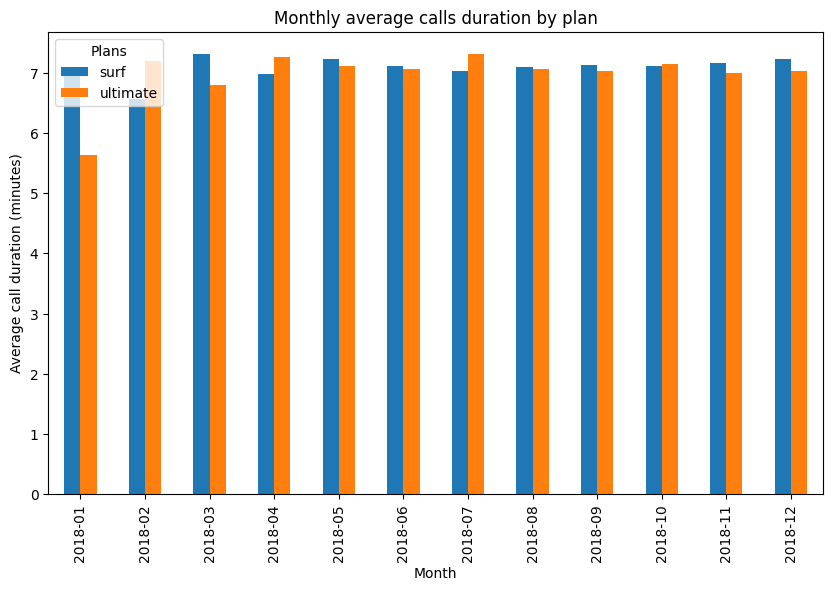

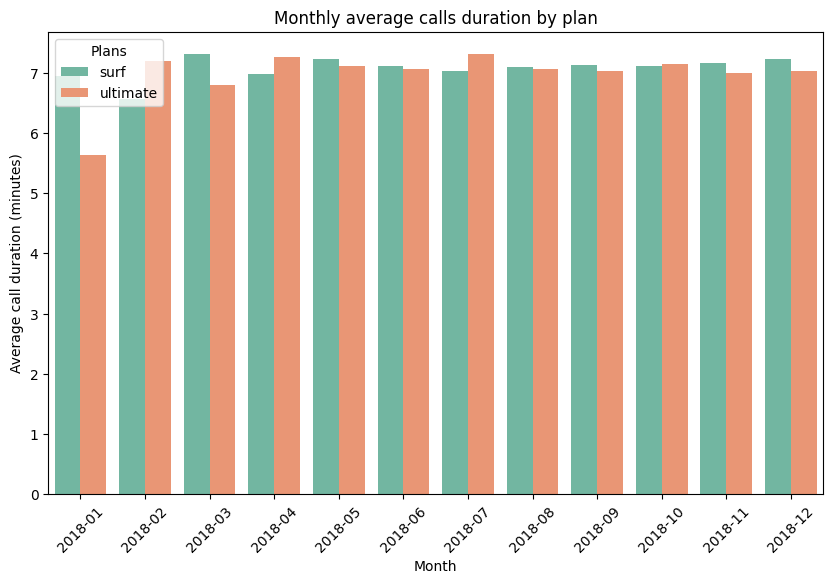

In [31]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.
df_info_plans['avg_call_duration'] = df_info_plans['minutes_used'] / df_info_plans['calls_count']
avg_duration_by_plan = df_info_plans.groupby(['plan_name', 'monthly_period'])['avg_call_duration'].mean().reset_index()
print('\nDuração média das chamadas por plano e mês:')
display(avg_duration_by_plan)


pivot_data = avg_duration_by_plan.pivot(index='monthly_period', 
                                        columns='plan_name', values='avg_call_duration')

pivot_data.plot(kind='bar', xlabel='Month', ylabel='Average call duration (minutes)', 
                title='Monthly average calls duration by plan', figsize=(10,6))
plt.legend(title='Plans')
plt.show()


plt.figure(figsize=(10,6))
sns.barplot(data=avg_duration_by_plan,
           x='monthly_period',
           y='avg_call_duration',
           hue='plan_name',
           palette='Set2')
plt.title('Monthly average calls duration by plan')
plt.xlabel('Month')
plt.ylabel('Average call duration (minutes)')
plt.legend(title='Plans')
plt.xticks(rotation=45)
plt.show()


***Inicialmente, calculei a duração média das chamadas que cada usuário fez no mês dividindo os minutos totais gastos pela quantidade de chamadas efetuadas e criei uma coluna com esses dados. O agrupamento foi feito para visualizar a média de chamadas por plano e mês.***

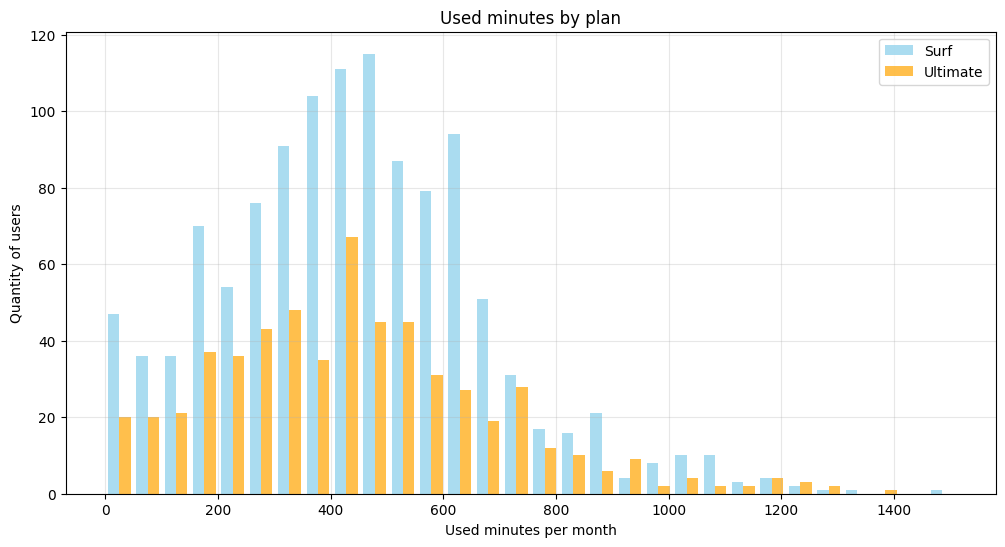

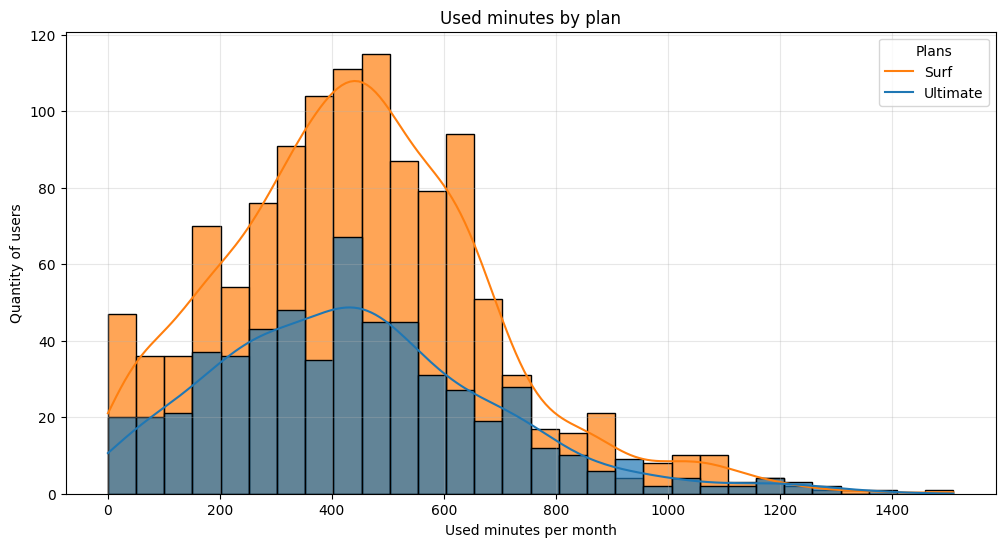

In [32]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.

plt.figure(figsize=(12, 6))

surf_minutes = df_info_plans[df_info_plans['plan_name'] == 'surf']['minutes_used']
ultimate_minutes = df_info_plans[df_info_plans['plan_name'] == 'ultimate']['minutes_used']

plt.hist([surf_minutes, ultimate_minutes], 
         bins=30, 
         alpha=0.7, 
         label=['Surf', 'Ultimate'],
         color=['skyblue', 'orange'])

plt.xlabel('Used minutes per month')
plt.ylabel('Quantity of users')
plt.title('Used minutes by plan')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(data=df_info_plans, 
             x='minutes_used', 
             hue='plan_name',
             bins=30, 
             alpha=0.7,
             kde=True)
plt.xlabel('Used minutes per month')
plt.ylabel('Quantity of users')
plt.title('Used minutes by plan')
plt.legend(title='Plans', labels=['Surf', 'Ultimate'])
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
# Calcule a média e a variância da duração mensal das chamadas
stats_summary = df_info_plans.groupby('plan_name')['minutes_used'].agg(['mean', 'var', 'std'])
print('=' * 45)
print("Resumo estatístico por plano(minutos usados):".center(45))
print('=' * 45)
display(stats_summary)

Resumo estatístico por plano(minutos usados):


,mean,var,std
plan_name,,,
surf,445.775424,55321.412627,235.205044
ultimate,442.512953,62288.399053,249.576439


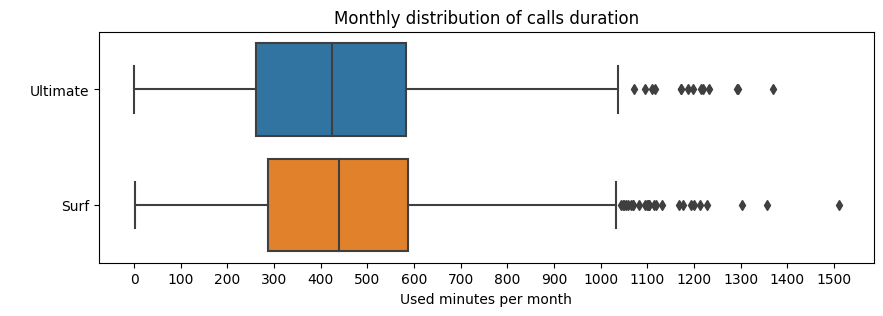

In [34]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
plt.figure(figsize=(10, 3))
sns.boxplot(data=df_info_plans, 
            y='plan_name', 
            x='minutes_used')
plt.title('Monthly distribution of calls duration')
plt.ylabel(' ')
plt.xlabel('Used minutes per month')
plt.yticks([0, 1], ['Ultimate', 'Surf'])
plt.xticks(range(0, 1501, 100))
plt.show()

***Nota-se que a média de minutos utilizados por usuário por mês é bem similar entre os planos, destaque para a quantidade de usuários do plano Surf que ultrapassam os minutos contratados em comparação com esse mesmo quantitativo relacionado ao plano Ultimate. O plano Surf também traz uma maior quantidade de valores atípicos acima da máxima, representados pelos usuários com consumos extremos, muito superior ao padrão geral do plano.***

### Mensagens

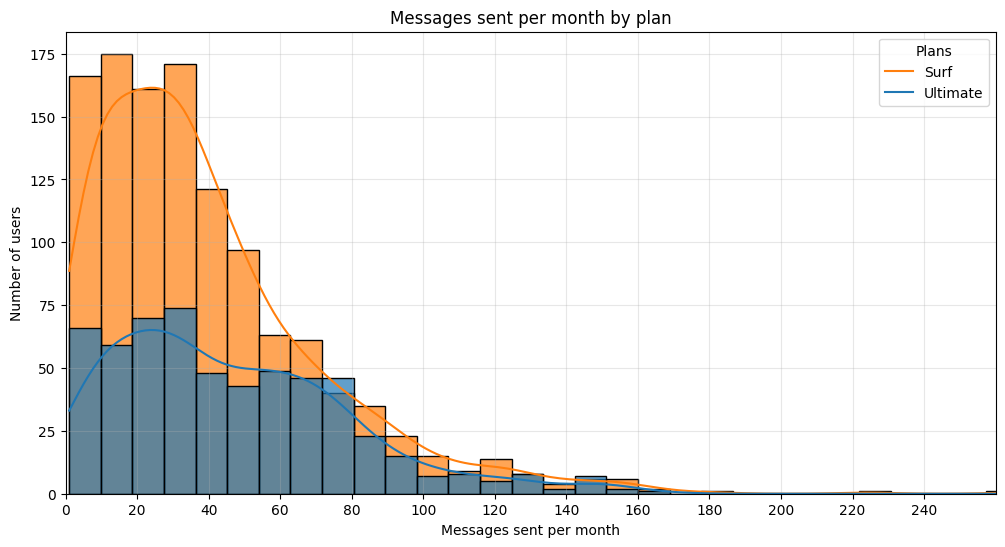

In [35]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês
plt.figure(figsize=(12, 6))
sns.histplot(data=df_info_plans,
            x='message_used',
            hue='plan_name',
            bins=30,
            alpha=0.7,
            kde=True)
plt.title('Messages sent per month by plan')
plt.xlabel('Messages sent per month')
plt.ylabel('Number of users')
plt.xticks(range(0, 260, 20))
plt.xlim(0, 260)
plt.legend(title='Plans', labels=['Surf', 'Ultimate'])
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
message_stats = df_info_plans.groupby('plan_name')['message_used'] \
    .agg(['mean', 'median', 'var', 'std', 'min', 'max'])
print('=' * 60)
print("Estatísticas de mensagens por mês:".center(60))
print('=' * 60)
display(message_stats)

             Estatísticas de mensagens por mês:             


,mean,median,var,std,min,max
plan_name,,,,,,
surf,39.489831,32,1044.217878,32.314360,1,266
ultimate,46.455959,41,1084.393818,32.930135,1,166


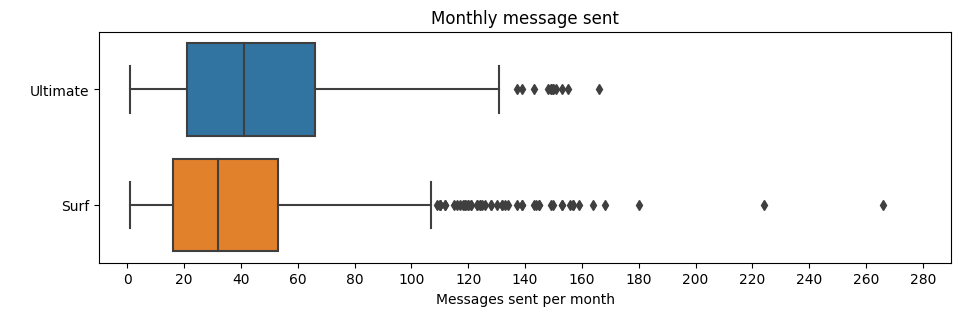

In [37]:
plt.figure(figsize=(11, 3))
sns.boxplot(data=df_info_plans, 
            y='plan_name', 
            x='message_used')
plt.title('Monthly message sent')
plt.ylabel(' ')
plt.xlabel('Messages sent per month')
plt.yticks([0, 1], ['Ultimate', 'Surf'])
plt.xticks(range(0, 281, 20))
plt.xlim(-10, 290)
plt.show()

***Sobre o consumo de mensagens, temos algo similar com o que foi visto sobre as chamadas. Contudo, aqui há uma singela superioridade na média do envio de mensagens pelos usuários do plano Ultimate.***

### Internet

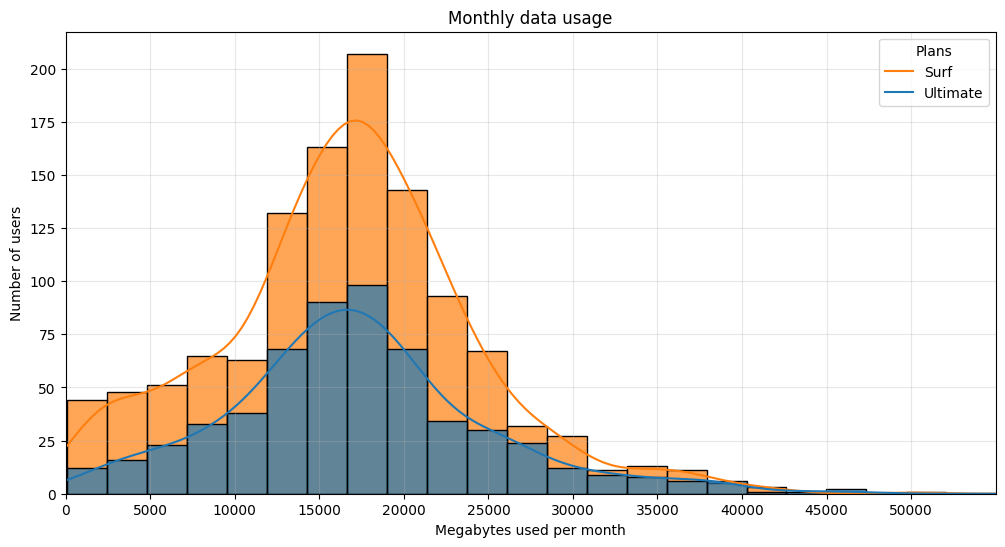

In [38]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
plt.figure(figsize=(12, 6))
sns.histplot(data=df_info_plans,
            x='mb_count',
            hue='plan_name',
            bins=30,
            alpha=0.7,
            kde=True)
plt.title('Monthly data usage')
plt.xlabel('Megabytes used per month')
plt.ylabel('Number of users')
plt.xticks(range(0, 50001, 5000))
plt.xlim(0, 55000)
plt.legend(title='Plans', labels=['Surf', 'Ultimate'])
plt.grid(True, alpha=0.3)
plt.show()


In [39]:
internet_stats = df_info_plans.groupby('plan_name')['mb_count'] \
    .agg(['mean', 'median', 'var', 'std', 'min', 'max'])
print('=' * 60)
print("Consumo de dados por mês (em MB):".center(60))
print('=' * 60)
display(message_stats)

             Consumo de dados por mês (em MB):              


,mean,median,var,std,min,max
plan_name,,,,,,
surf,39.489831,32,1044.217878,32.314360,1,266
ultimate,46.455959,41,1084.393818,32.930135,1,166


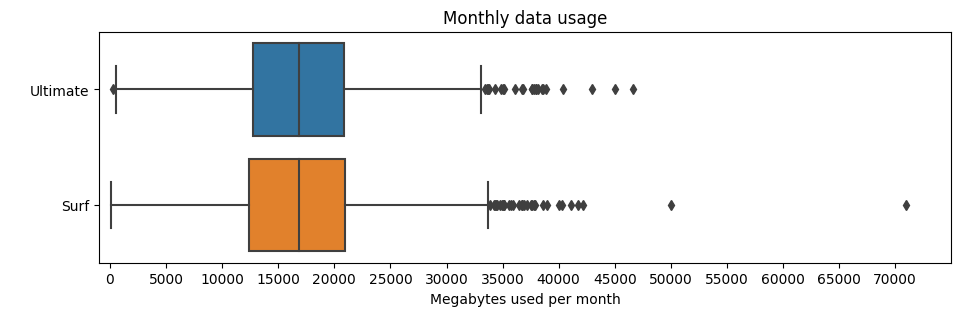

In [40]:
plt.figure(figsize=(11, 3))
sns.boxplot(data=df_info_plans, 
            y='plan_name', 
            x='mb_count')
plt.title('Monthly data usage')
plt.ylabel(' ')
plt.xlabel('Megabytes used per month')
plt.yticks([0, 1], ['Ultimate', 'Surf'])
plt.xticks(range(0, 70001, 5000))
plt.xlim(-1000, 75000)
plt.show()

***De uma maneira geral, o comportamento dos usuários em relação a consumo de dados, mensagens ou chamadas é consistente. De modo que, em todas as situações, mais usuários do plano Surf consumiram mais que o contratado. É possível visualizar, p.ex., o consumo de dados trazido pelo boxplot possui maior parte dos usuários do plano Surf com excedentes de consumo, o que não acontece com os usuários do plano Ultimate.***

In [41]:
display(df_info_plans)

,user_id,monthly_period,calls_count,minutes_used,message_used,mb_count,plan_name,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,total_monthly_expense,avg_call_duration
0,1000,2018-12,16,124,11,1903,ultimate,1000,30720,3000,70,7,0.01,0.01,70.000,7.750000
1,1006,2018-11,2,10,15,2072,ultimate,1000,30720,3000,70,7,0.01,0.01,70.000,5.000000
2,1006,2018-12,9,59,139,32144,ultimate,1000,30720,3000,70,7,0.01,0.01,79.968,6.555556
3,1008,2018-10,71,476,21,17131,ultimate,1000,30720,3000,70,7,0.01,0.01,70.000,6.704225
4,1008,2018-11,63,446,37,23706,ultimate,1000,30720,3000,70,7,0.01,0.01,70.000,7.079365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1754,1496,2018-08,18,122,2,8616,surf,50,15360,500,20,10,0.03,0.03,20.000,6.777778
1755,1496,2018-09,52,414,21,16412,surf,50,15360,500,20,10,0.03,0.03,30.520,7.961538
1756,1496,2018-10,46,317,18,14308,surf,50,15360,500,20,10,0.03,0.03,20.000,6.891304
1757,1496,2018-11,39,308,13,8561,surf,50,15360,500,20,10,0.03,0.03,20.000,7.897436


## Receita

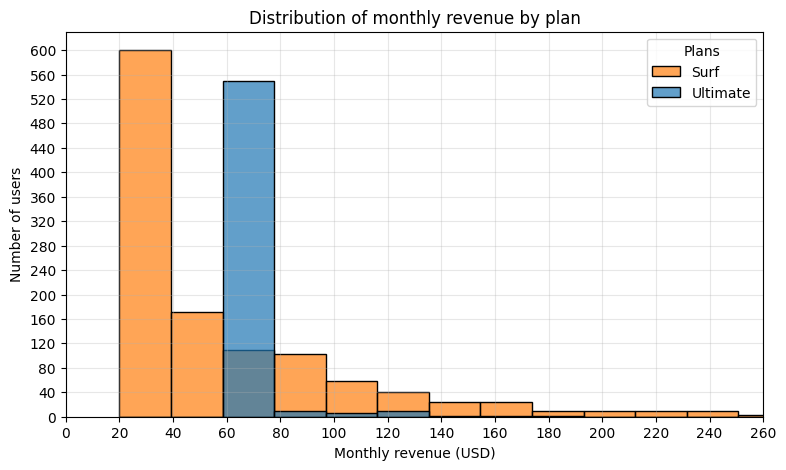

In [42]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df_info_plans, 
             x='total_monthly_expense', 
             hue='plan_name', 
             bins=30, 
             alpha=0.7)
plt.title('Distribution of monthly revenue by plan')
plt.xlabel('Monthly revenue (USD)')
plt.ylabel('Number of users')
plt.legend(title='Plans', labels=['Surf', 'Ultimate'])
plt.grid(True, alpha=0.3)
plt.yticks(range(0, 601, 40))
plt.xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260])
plt.xlim(0, 260)
plt.show()

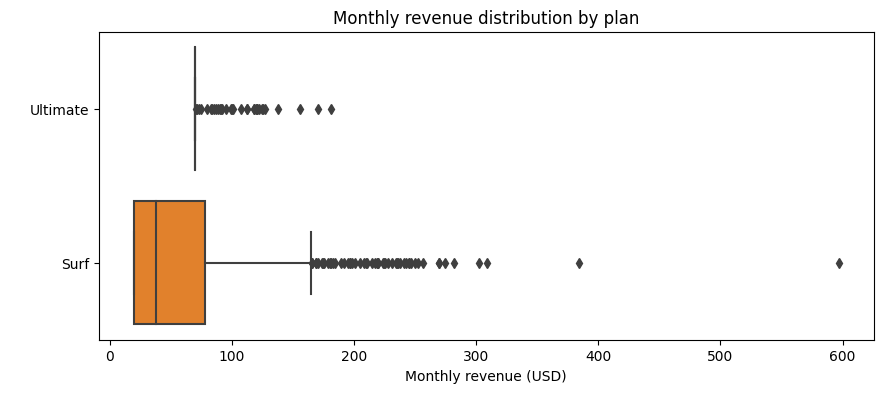

In [43]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_info_plans, 
            y='plan_name', 
            x='total_monthly_expense')
plt.title('Monthly revenue distribution by plan')
plt.ylabel(' ')
plt.xlabel('Monthly revenue (USD)')
plt.yticks([0, 1], ['Ultimate', 'Surf'])
plt.show()

In [44]:
print('=' * 72)
print("Estatísticas descritivas das receitas por plano:".center(72))
print('=' * 72)
revenue_stats = df_info_plans.groupby('plan_name')['total_monthly_expense'].describe()
display(revenue_stats)

            Estatísticas descritivas das receitas por plano:            


,count,mean,std,min,25%,50%,75%,max
plan_name,,,,,,,,
surf,1180.0,58.269008,53.294236,20.0,20.0225,38.095,78.15,596.650
ultimate,579.0,72.125908,10.780856,70.0,70.0000,70.000,70.00,181.398


In [45]:
surf_users = df_info_plans[df_info_plans['plan_name'] == 'surf']['total_monthly_expense']
minimum_surf_value = surf_users.min()
print('=' * 55)
print('Métricas relevantes do plano Surf:'.center(55))
print('=' * 55)

surf_users_above_minimum = (surf_users > minimum_surf_value).sum()
surf_total_users = len(surf_users)

print(f"Total de usuários: {surf_total_users}")
print(f"Quantidade de usuários que pagam mais que o mínimo: {surf_users_above_minimum}")

percentage = (surf_users_above_minimum / surf_total_users) * 100
print(f"Porcentagem que paga mais que o mínimo: {percentage:.1f}%")

print()
print()

ultimate_users = df_info_plans[df_info_plans['plan_name'] == 'ultimate']['total_monthly_expense']
minimum_ultimate_value = ultimate_users.min()
print('=' * 55)
print('Métricas relevantes do plano Ultimate:'.center(55))
print('=' * 55)

ultimate_users_above_minimum = (ultimate_users > minimum_ultimate_value).sum()
ultimate_total_users = len(ultimate_users)

print(f"Total de usuários: {ultimate_total_users}")
print(f"Quantidade de usuários que pagam mais que o mínimo: {ultimate_users_above_minimum}")

percentage = (ultimate_users_above_minimum / ultimate_total_users) * 100
print(f"Porcentagem que paga mais que o mínimo: {percentage:.1f}%")
print()

           Métricas relevantes do plano Surf:          
Total de usuários: 1180
Quantidade de usuários que pagam mais que o mínimo: 885
Porcentagem que paga mais que o mínimo: 75.0%


         Métricas relevantes do plano Ultimate:        
Total de usuários: 579
Quantidade de usuários que pagam mais que o mínimo: 33
Porcentagem que paga mais que o mínimo: 5.7%



In [46]:
excess_by_plan = df_info_plans.groupby('plan_name').agg({'total_monthly_expense': 'sum',
                                                         'usd_monthly_pay': 'sum'}).reset_index()

excess_by_plan['excess_revenue'] = (excess_by_plan['total_monthly_expense'] - 
                                   excess_by_plan['usd_monthly_pay'])
excess_by_plan['excess_percentage'] = (excess_by_plan['excess_revenue'] / 
                                      excess_by_plan['total_monthly_expense']) * 100

print('=' * 82)
print("Análise por plano:".center(82))
print('=' * 82)
display(excess_by_plan)

                                Análise por plano:                                


,plan_name,total_monthly_expense,usd_monthly_pay,excess_revenue,excess_percentage
0,surf,68757.430,23600,45157.430,65.676437
1,ultimate,41760.901,40530,1230.901,2.947496


__Análise sobre receita:__

***Ao observar os gráficos e as tabelas, conclui-se que:***

*- o boxplot de Ultimate aparece como uma linha, ou seja, maior parte dos usuários paga exatamente o valor fixo do plano (70 USD) → Q1 (25%), mediana (Q2/50%) e Q3 (75%) possuem o mesmo valor*

*- poucos usuários excedem os limites incluídos no plano*

*- os usuários do plano Ultimate possuem limites que atendem melhor às suas necessidades*

*- o plano Ultimate gera uma receita mais previsível, tendo em vista o comportamento dos usuários*

*- já o plano Surf traz usuários com receitas mais variadas (alguns pagam só o básico, outros muito mais)*

*- o plano Surf é um plano mais básico e acessível aos usuários, com um custo mínimo menor e que possui maior adesão por parte do público, além de 75% de seus usuários pagarem valores maiores que o mínimo por excedentes de uso*

*- o excedente pago pelos usuários do plano Surf equivale a 65% da receita total do plano*


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

- Todas as análises realizadas corretamente!
- Graficos muito bons!

## Teste hipóteses estatísticas

In [47]:
# Teste as hipóteses
surf_revenue = df_info_plans[df_info_plans['plan_name'] == 'surf']['total_monthly_expense']
ultimate_revenue = df_info_plans[df_info_plans['plan_name'] == 'ultimate']['total_monthly_expense']

print('=' * 35)
print('Estatísticas descritivas:'.center(35))
print('=' * 35)

print(f'Receita média Surf: ${surf_revenue.mean():.2f}')
print(f'Receita média Ultimate: ${ultimate_revenue.mean():.2f}')
print(f'Diferença entre as receitas: ${ultimate_revenue.mean() - surf_revenue.mean():.2f}')

alpha = .05
statistic, p_value = st.ttest_ind(ultimate_revenue, surf_revenue)

print()
print()
print('=' * 21)
print('Teste de hipóteses:'.center(21))
print('=' * 21)
print(f"Estatística t: {statistic:.4f}")
print(f"Valor_p: {p_value:.6f}")
print(f"Alfa: {alpha}")
print()

     Estatísticas descritivas:     
Receita média Surf: $58.27
Receita média Ultimate: $72.13
Diferença entre as receitas: $13.86


 Teste de hipóteses: 
Estatística t: 6.1937
Valor_p: 0.000000
Alfa: 0.05



In [48]:
# Teste as hipóteses
print("Cidades únicas no dataset:")
print()
print(df_users['city'].unique())

if 'city' not in df_info_plans.columns:
    df_info_plans = df_info_plans.merge(df_users[['user_id', 'city']], on='user_id', how='left')

ny_nj_cities = ['New York-Newark-Jersey City, NY-NJ-PA MSA']
df_info_plans['region'] = np.where(df_info_plans['city'].isin(ny_nj_cities), 'NY-NJ', 'Other')

ny_nj_revenue = df_info_plans[df_info_plans['region'] == 'NY-NJ']['total_monthly_expense']
other_regions_revenue = df_info_plans[df_info_plans['region'] == 'Other']['total_monthly_expense']

print()
print(' - ' * 36)
print()
print('=' * 35)
print('Estatísticas descritivas:'.center(35))
print('=' * 35)
print(f'Receita média NY-NJ: ${ny_nj_revenue.mean():.2f}')
print(f'Receita média Demais regiões: ${other_regions_revenue.mean():.2f}')
print(f'Diferença entre as receitas: ${other_regions_revenue.mean() - ny_nj_revenue.mean():.2f}')

alpha = .05
statistic, p_value = st.ttest_ind(other_regions_revenue, ny_nj_revenue)

print()
print()
print('=' * 21)
print('Teste de hipóteses:'.center(21))
print('=' * 21)
print(f"Estatística t: {statistic:.4f}")
print(f"Valor_p: {p_value:.6f}")
print(f"Alfa: {alpha}")
print()

Cidades únicas no dataset:

['Atlanta-Sandy Springs-Roswell, GA MSA' 'Seattle-Tacoma-Bellevue, WA MSA'
 'Las Vegas-Henderson-Paradise, NV MSA' 'Tulsa, OK MSA'
 'Dallas-Fort Worth-Arlington, TX MSA'
 'San Francisco-Oakland-Berkeley, CA MSA' 'Grand Rapids-Kentwood, MI MSA'
 'Orlando-Kissimmee-Sanford, FL MSA'
 'San Jose-Sunnyvale-Santa Clara, CA MSA' 'Cleveland-Elyria, OH MSA'
 'Chicago-Naperville-Elgin, IL-IN-WI MSA' 'Knoxville, TN MSA'
 'New York-Newark-Jersey City, NY-NJ-PA MSA' 'Pittsburgh, PA MSA'
 'Fresno, CA MSA' 'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA'
 'Indianapolis-Carmel-Anderson, IN MSA' 'Jacksonville, FL MSA'
 'Los Angeles-Long Beach-Anaheim, CA MSA'
 'Omaha-Council Bluffs, NE-IA MSA'
 'Houston-The Woodlands-Sugar Land, TX MSA'
 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA'
 'Tampa-St. Petersburg-Clearwater, FL MSA' 'Birmingham-Hoover, AL MSA'
 'Oklahoma City, OK MSA' 'Charlotte-Concord-Gastonia, NC-SC MSA'
 'Denver-Aurora-Lakewood, CO MSA'
 'Nashville-Davidson

<div class="alert alert-block alert-success">
  <b>Comentário:</b> <a class="tocSkip"></a>

-  Os dois testes foram implementados corretamente.


Dica: realizar as análises de variância, utilizar o argumento `equal_var=False`


</div>

## Conclusão geral

***Conforme teste de hipótese sobre a receita média dos usuários dos planos Ultimate e Surf, obtive p_value < .05, nesse caso os dados nos dão motivos para rejeitar a hipótese nula, é muito improvável que a significativa diferença entre os planos aconteça por acaso.***

***Por fim, ressalto que a diferença de 6.19 desvios padrão traz a confirmação de que a receita média do plano Ultimate é significativamente maior que a do plano Surf. Trata-se de uma diferença muito grande e estatisticamente robusta de modo que convém ao departamento comercial focar mais investimento em publicidade no plano Ultimate.***

***Já conforme o teste de hipótese sobre a receita média dos usuários da área de NY-NJ em realção à receita média dos usuários das demais regiões concluímos mais uma vez que os dados nos dão motivos para rejeitar a hipótese nula, uma vez que p_value < .05, logo é improvavél a diferença observada entre as receitas médias das duas regiões seja devido ao acaso.***

***Mais uma vez, observamos que a diferença entre as receitas médias ($7.75) é estatisticamente significativa. Interessante observar também que os usuários de NY-NJ têm receita média menor (56.31) comparado às demais regiões (64.06). Por último, ressalto que a diferença de 2.67 desvios padrão é de efeito moderado, ou seja, não trata-se de uma coincidência (é estatisticamente significativa), vale a pena investigar (é Comercialmente relevante) e é substancial (moderadamente importante).***

<div class="alert alert-block alert-success">
  <b>Comentário:</b> <a class="tocSkip"></a>

Boa conclusão! Baseada em dados :) 